## Imports

In [2]:
from keras import layers, optimizers, Input, Model, callbacks, regularizers
from methods.load_data import load_ucsf
from methods.visualisation import plot_training_history, plot_tumour

IMAGE_SIZE = 64

loading dataset...


KeyboardInterrupt: 

## Get dataset

loading dataset...
dataset loaded.
Training shape: x_train - (9300, 64, 64, 3), y_train - (9300,)
Validation shape: x_val - (3720, 64, 64, 3), y_val - (3720,)
Testing shape: x_test - (2480, 64, 64, 3), y_test - (2480,)


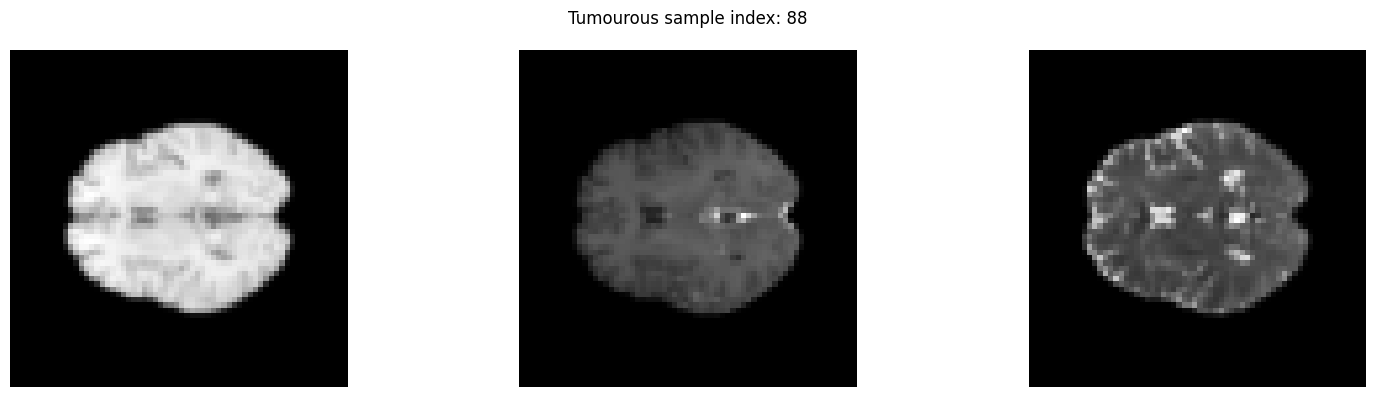

In [ ]:
x_train, y_train, x_val, y_val, x_test, y_test = load_ucsf(debug=True, classification=True, image_size=IMAGE_SIZE)
print(f"Training shape: x_train - {x_train.shape}, y_train - {y_train.shape}")
print(f"Validation shape: x_val - {x_val.shape}, y_val - {y_val.shape}")
print(f"Testing shape: x_test - {x_test.shape}, y_test - {y_test.shape}")
plot_tumour(x_train, y_train)

## Construct model

In [ ]:
regulariser = regularizers.l2(1e-4)
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=regulariser)(inputs)
x = layers.Dropout(0.5)(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=regulariser)(x)
x = layers.Dropout(0.5)(x)
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same", kernel_regularizer=regulariser)(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same", kernel_regularizer=regulariser)(x)
x = layers.Dropout(0.3)(x)
x = layers.Flatten()(x)
output = layers.Dense(1, activation="sigmoid")(x)
model = Model(inputs=inputs, outputs=output)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,801 (38.29 KB)

 Trainable params: 9,801 (38.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compile model

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["AUC"]
)

## Fit model

In [ ]:
BATCH_SIZE = 32
EPOCHS = 20

def get_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),
        callbacks.ModelCheckpoint(
            filepath="models/best_classification_model.keras",
            monitor="val_AUC",
            save_best_only=True,
            mode="max"
        )
    ]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    callbacks=get_callbacks(),
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - AUC: 0.7093 - loss: 2.6998 - val_AUC: 0.7670 - val_loss: 1.2472
Epoch 2/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - AUC: 0.8125 - loss: 1.0656 - val_AUC: 0.8029 - val_loss: 1.1608
Epoch 3/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - AUC: 0.8574 - loss: 0.7885 - val_AUC: 0.8051 - val_loss: 1.0319
Epoch 4/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - AUC: 0.8777 - loss: 0.6469 - val_AUC: 0.8051 - val_loss: 0.9408
Epoch 5/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - AUC: 0.8997 - loss: 0.5344 - val_AUC: 0.8168 - val_loss: 0.9294
Epoch 6/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - AUC: 0.9174 - loss: 0.4441 - val_AUC: 0.8195 - val_loss: 0.9047
Epoch 7/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - AUC: 0.9263 - loss: 0.4113 - val_AUC: 0.8192 - val_loss: 0.8510
Epoch 8/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - AUC: 0.9347 - loss: 0.3662 - val_AUC: 0.8174 - val_loss: 0.9220
Epoch 9/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/

## Plot training and validation history

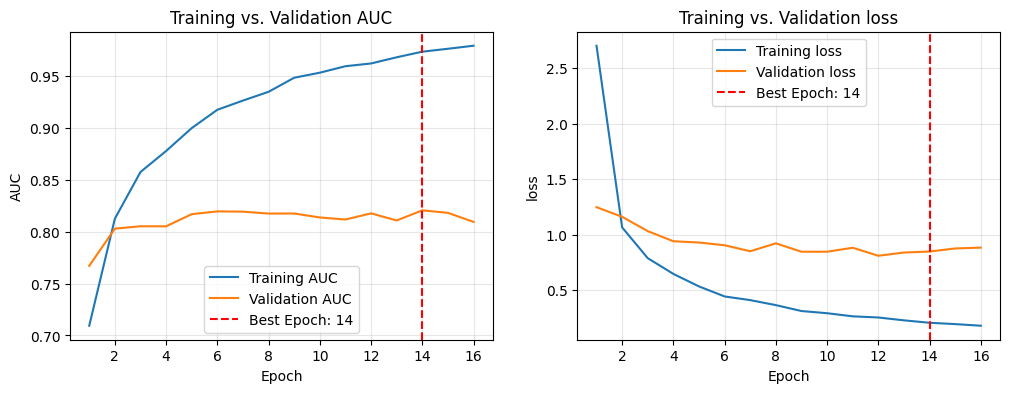

In [ ]:
plot_training_history(history, "AUC", "loss")

## Evaluate model

In [ ]:
loss, auc = model.evaluate(x_test, y_test)
print(f"Test loss: {loss}, Test AUC: {auc}")

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - AUC: 0.8341 - loss: 1.0018
Test loss: 1.0017552375793457, Test AUC: 0.8340886235237122


## Notes
Plateauing around 80% AUC, validation loss is flat, best epoch is found early. Model started overfitting to quickly so implemented regulariser and dropout.